In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("../data/processed/feature_engineered_data.csv")

In [106]:
data.head()

,age,fatigue_severity_scale_score,depression_phq9_score,pem_present,pem_duration_hours,brain_fog_level,physical_pain_score,stress_level,hours_of_sleep_per_night,diagnosis,social_activity_level,exercise_frequency,work_status_Partially_working,work_status_Not_working,gender_Female,meditation_or_mindfulness_No
0,0.435644,-0.5,0.000000,0,-0.629213,-0.431818,0.857143,0.642857,0.314286,0,1,4,0,0,0,0
1,0.950495,0.0,1.666667,1,0.808989,0.931818,-0.333333,1.071429,0.514286,2,1,3,0,0,0,0
2,0.039604,-5.4,2.333333,0,-0.449438,-0.090909,-0.190476,0.000000,0.085714,0,0,1,1,0,1,0
3,-0.514851,-0.2,0.000000,0,-0.539326,-0.840909,-0.642857,-0.380952,0.257143,0,3,0,0,1,1,0
4,0.594059,0.0,1.166667,1,1.033708,0.386364,0.190476,0.738095,-1.000000,2,1,1,0,1,1,1


In [107]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   float64
 1   fatigue_severity_scale_score   1000 non-null   float64
 2   depression_phq9_score          1000 non-null   float64
 3   pem_present                    1000 non-null   int64  
 4   pem_duration_hours             1000 non-null   float64
 5   brain_fog_level                1000 non-null   float64
 6   physical_pain_score            1000 non-null   float64
 7   stress_level                   1000 non-null   float64
 8   hours_of_sleep_per_night       1000 non-null   float64
 9   diagnosis                      1000 non-null   int64  
 10  social_activity_level          1000 non-null   int64  
 11  exercise_frequency             1000 non-null   int64  
 12  work_status_Partially_working  1000 non-null   in

In [108]:
data.shape

(1000, 16)

---
---

1. **Виберіть техніку моделювання, яка підходить для вирішення задачі 
вашого підприємства. Обґрунтуйте, чому саме класифікація, регресія або інший 
підхід є релевантним до вашої бізнес-проблеми.**

---
---

Насамперед, давайте пригадаємо, з яким запитом звернувся до мене бізнес: \
`"Нестача інструментів, які точно розрізняють МЕ/СФС та депресію, призводить до неправильних діагнозів. Центр шукає рішення для покращення точності діагностики."`

Судячи запити, та пригадавши саму проблему бізнесу, я маю тип навчання - `supervised learning`, а саме - задача **класифікації**. Тому що, головна мета бізнесу - покращити технології розпізнавання різних діагнозів, а діагнози ми можемо інтерпреувати як класи, яких є 3. Тобто, моя задача буде побудувати таку модель, яка буде якнайкраще розрізняти ці класи, а найбільш важливо, покращить роботу бізнесу.

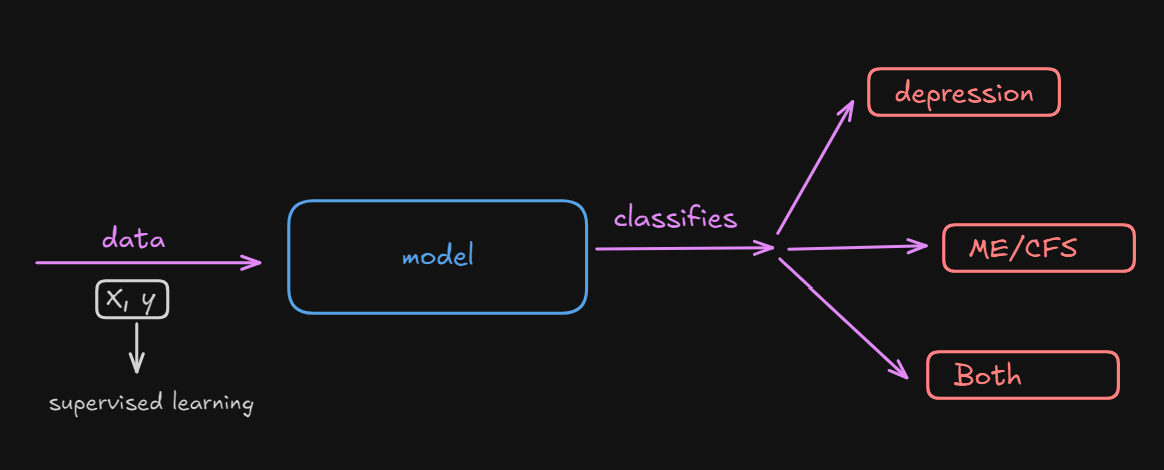

----
---

2. **.Опишіть модельне припущення. У звіті до лабораторної поясніть, які 
припущення робить обрана модель (наприклад, лінійність, незалежність 
змінних, балансованість класів) і наскільки вони виконуються у ваших даних.**

---
----

**Відсутність пропущених даних** \
Багато моделей є доволі чутливими до пропущених даних тому треба це враховувати.
В мому ж випадку я попередньо зробив feature engineering, тому пропущені дані в мене відусутні


**Збалансованість класів** \
Так як в мене задача класифікації, то дуже важливо мати збалансованість класів. Тому що, якшо в датасеті є якись один переважаючий клас(наприклад 90%) то модель може добре завчити як визначати той популярний клас, але інший клас - з ним будуть проблеми.
В мому ж випадку, я маю таку статистику:
  - depression: 0.401
  - ME/CFS: 0.397
  - Both: 0.202 

  Тобто я маю помітну, але не велику збалансованість. Це може трохи повпливати на такі моделі як логістична регресія, або SVM, тому можливо треба буде задуматися над балансуванням класів


**Чутливість до масштабу** \
Якщо брати до уваги моделі, які чутливі до масштабу, такі як KNN, SVM, то дуже важливо мати дані одного масштабу. Бо наприклад, ми моджемо мати одну фіяу яка має розмір 1-10, тоді як інша від 1 до 100 000, і це призовдить до такого явища як "cusre of dimensionality".
В мому ж випадку, дані попередньо машстабовані, тому це є плюсом.


**Лінійність**
Деякі моделі, як логістияна регресія,передбачають приблизно лінійну залежність між ознаками та відгуком (response), тоді як моделі на основі дерев рішень не мають такого обмеження. \
В мому ж випадку я маю лінйну залежність, а деякі фічі мають доволі велику:
  - pem_present: 0.873139
  - fatigue_severity_scale_score: 0.508295


Зробивши аналіз, я можу зробити припущення, що логістична регресія або інші лінійні моделі можуть підійти для цієї задачі.

In [109]:
data["diagnosis"].value_counts()

diagnosis
0    401
1    397
2    202
Name: count, dtype: int64

- 0: `depression`
- 1: `ME/CFS`
- 2: `Both`

<Axes: xlabel='diagnosis', ylabel='count'>

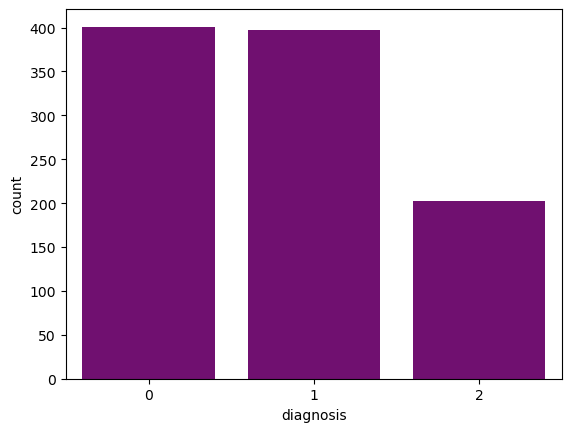

In [110]:
sns.countplot(data=data, x="diagnosis", color="purple")

In [111]:
values = data["diagnosis"].value_counts()
n = data.shape[0]

for index, value in enumerate(values):
  print(f"{index}: {value / n}")
  

0: 0.401
1: 0.397
2: 0.202


In [112]:
data.corr()[["diagnosis"]]

,diagnosis
age,0.010406
fatigue_severity_scale_score,0.508295
depression_phq9_score,-0.053017
pem_present,0.873139
pem_duration_hours,0.004929
brain_fog_level,0.022552
physical_pain_score,0.026102
stress_level,0.017940
hours_of_sleep_per_night,-0.010757
diagnosis,1.000000


<Axes: xlabel='fatigue_severity_scale_score', ylabel='diagnosis'>

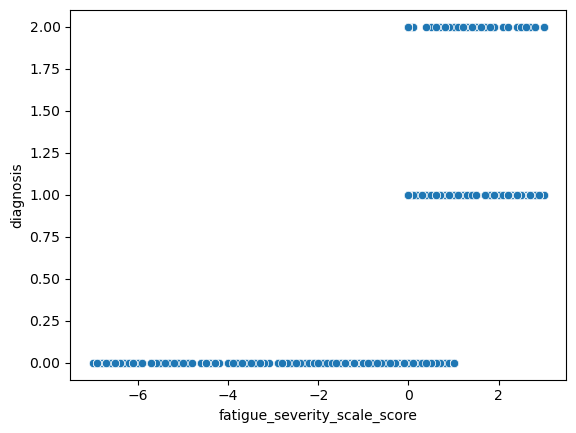

In [113]:
sns.scatterplot(data=data, x="fatigue_severity_scale_score", y="diagnosis")

In [114]:
data.groupby('pem_present')["diagnosis"].mean()


pem_present
0    0.000000
1    1.337229
Name: diagnosis, dtype: float64

---
---

**3. Оберіть 2–3 релевантні метрики для оцінки моделі. Наприклад: 
accuracy, F1-score, recall, precision, MAE, RMSE — залежно від типу задачі. 
Обґрунтуйте, чому саме ці метрики відповідають вашій меті.**

---
---


Насамперед, хочу знову згадати запит бізнесу: \
`"Нестача інструментів, які точно розрізняють МЕ/СФС та депресію, призводить до неправильних діагнозів. Центр шукає рішення для покращення точності діагностики."`

Тобто, так як це медична сфера, нам важливо мінімізувати кількість неправильно визначених діагнозів(класів).

Так, як в мене задача класифікації, я буду використовувтаи метрики, які призначені для цієї проблеми:
- `F1-score`: ця метрика в собі поєднує інші дві не менш важливі метрики - recall та precision. Це чи не єдина оцінка, яка може оцінити модель збалансовано (тому що я маю не велику незбалансованість класів)
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
- `Recall`: хоч вона і враховується в іншій метриці, але її можна оцінювати також окремо. Вона визначає: серед всіх true positive, скільки модель правильно класифікувала. Вона є важливою для моєї задачі, оскільки вона чим більше вона - тим менше випадків False Negatives, що є доволі важливо для медичної сфери
$$Recall = \frac{TP}{TP + FN}$$
- `ROC/AUC`: дає можливість оцінити загальну здатність моделі розрізняти класи (МЕ/СФС та Депресія) незалежно від обраного порогу класифікації, це особливо важливо в клінічному середовищі.

---
---

**4. Оберіть спосіб поділу даних на навчальні та тестові. Використовуйте 
класичний train_test_split або, за необхідності, TimeSeriesSplit чи 
StratifiedKFold. Поясніть логіку: наприклад, «оскільки дані мають часову 
природу — використовуємо розділення по часовій осі»**

---
---

In [115]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

X = data.drop(["diagnosis"], axis=1)
y = data["diagnosis"]

K = 5

Для цієї задачі я використав `StratifiedKfold`(реалізовано нижче). Знаючи, що в мене в датасеті є дизбаланс класів, дуже важливо проводити навчання та тестування справедливо, щоб кожна модель мала однакове співвідношення класів, щоб всі класи були рівномірно розподілені між всіма фолдами.

До того ж, крос-валідація надзвичайно ефективний метод для навчання та тестування моделі, оскільки протягом всіх етапів, модель буде протестована на всіх можливих даних

---
---

**5. Реалізуйте тренування моделей на ваших train-даних (отриманих з БД).
Модель має бути тренована автоматично через FastAPI-ендпоінт /train-model 
(як у попередній лабораторній). Результати тренування мають логуватись у 
таблицю predictions (source="train").**

**6. Проведіть валідацію моделей на тестовій вибірці. Підрахуйте метрики, 
збережіть їх у лог-файл або таблицю model_metrics у БД, щоб ви могли надалі 
порівнювати кілька моделей між собою.**

---
---

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis \
import QuadraticDiscriminantAnalysis as QDA, LinearDiscriminantAnalysis as LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, make_scorer, accuracy_score, recall_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

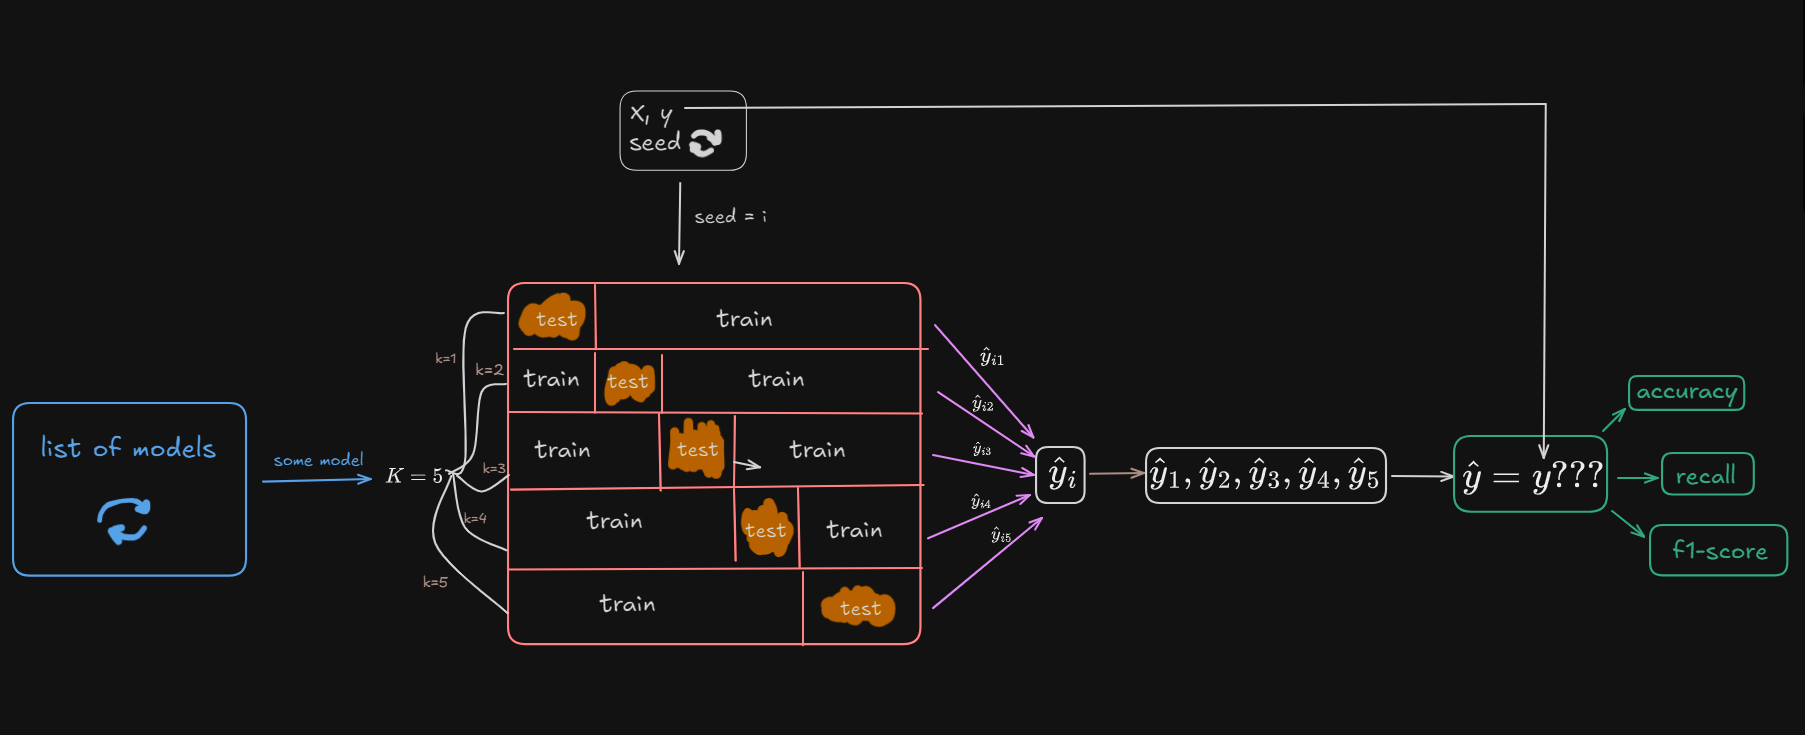

In [ ]:
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(),
    "QDA": QDA(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
}

results = []

for seed in range(5):  
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    new_results = []

    for name, model in models.items():
        y_hat = cross_val_predict(model, X, y, cv=skf)
        
        metrics = {
            "model": name,
            "accuracy": accuracy_score(y, y_hat),
            "f1_score": f1_score(y, y_hat, average="weighted"),
            "recall": recall_score(y, y_hat, average="weighted"),
            "run": seed
        }
        new_results.append(metrics)
    
    results.extend(new_results)

all_results = pd.DataFrame(results)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
c:\Users\Admin\anaconda3\Lib\site-

----
---

**7. Оберіть найкращу модель. Порівняйте метрики для всіх протестованих 
моделей. Обґрунтуйте свій вибір.**

**8. Проаналізуйте важливість ознак. Виведіть важливість ознак 
(наприклад, через .feature_importances_ у дерева або coef_ у лінійної моделі) і 
поясніть, які змінні найбільше впливають на передбачення.**

**9. Оберіть метрики для гіперпараметричної оптимізації. Наприклад, якщо 
модель має maximize F1-score, використовуйте її як цільову при тюнінгу.**

**10. Виберіть метод гіперпараметричної оптимізації. Можна використати 
GridSearchCV, RandomizedSearchCV, Optuna або Bayesian Optimization. 
Опишіть обрані гіперпараметри та їх діапазони.**

**11. Запустіть оптимізацію гіперпараметрів. Після підбору параметрів 
обов’язково збережіть найкращі значення, а також метрики до і після 
оптимізації у таблиці model_metrics.**

---
---

In [118]:
from datetime import datetime

summary = all_results.groupby("model")[["accuracy", "f1_score", "recall"]].agg(["mean", "std"]).round(3)
summary = summary.sort_values(("f1_score", "mean"), ascending=False)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_path = f"model_evaluation_{timestamp}.log"

with open(log_path, "w", encoding="utf-8") as f:
    f.write("=== Model Evaluation Summary ===\n\n")
    f.write(summary.to_string())
    f.write("\n\n=== Detailed Results per Run ===\n")
    f.write(all_results.to_string(index=False))

print(f"Результати збережено у файл: {log_path}")

with open(log_path, "r", encoding="utf-8") as f:
    log_content = f.read()
    
print(log_content)

Результати збережено у файл: model_evaluation_2025-10-15_18-55-28.log
=== Model Evaluation Summary ===

                    accuracy        f1_score        recall       
                        mean    std     mean    std   mean    std
model                                                            
Decision Tree          0.982  0.005    0.982  0.005  0.982  0.005
Logistic Regression    0.936  0.003    0.933  0.003  0.936  0.003
SVM                    0.926  0.002    0.922  0.003  0.926  0.002
NB                     0.917  0.002    0.911  0.002  0.917  0.002
KNN                    0.803  0.010    0.795  0.010  0.803  0.010
QDA                    0.738  0.053    0.739  0.059  0.738  0.053
LDA                    0.727  0.007    0.714  0.007  0.727  0.007

=== Detailed Results per Run ===
              model  accuracy  f1_score  recall  run
                KNN     0.811  0.802599   0.811    0
                 NB     0.918  0.911397   0.918    0
                LDA     0.737  0.725074   0

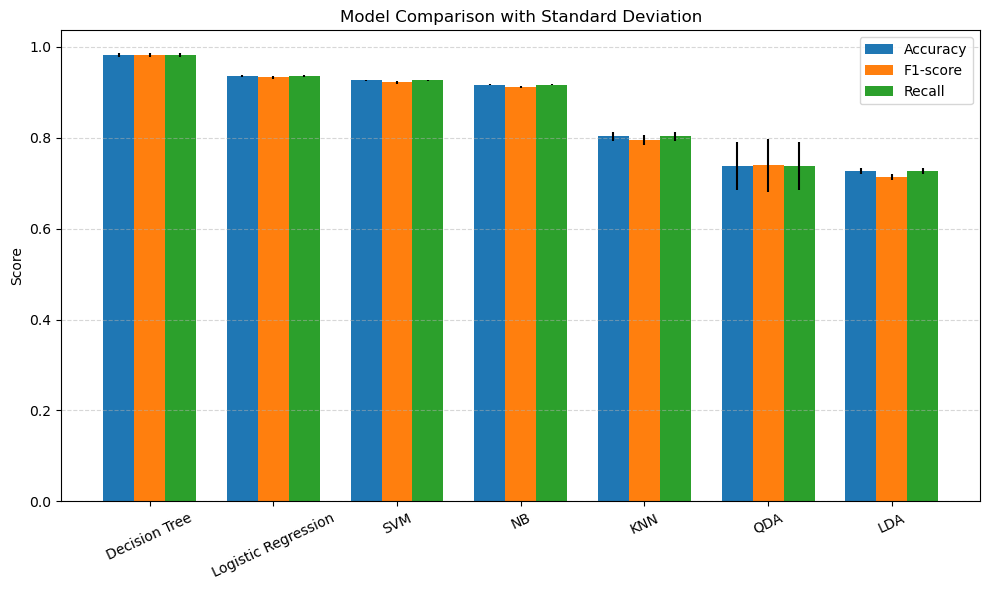

In [ ]:
summary_reset = summary.reset_index()  
summary_reset.columns = ['model', 
                         'accuracy_mean', 'accuracy_std',
                         'f1_mean', 'f1_std',
                         'recall_mean', 'recall_std']

plt.figure(figsize=(10,6))
x = np.arange(len(summary_reset))
width = 0.25

plt.bar(x - width, summary_reset["accuracy_mean"], width, yerr=summary_reset["accuracy_std"], label="Accuracy")
plt.bar(x, summary_reset["f1_mean"], width, yerr=summary_reset["f1_std"], label="F1-score")
plt.bar(x + width, summary_reset["recall_mean"], width, yerr=summary_reset["recall_std"], label="Recall")

plt.xticks(x, summary_reset["model"], rotation=25)
plt.ylabel("Score")
plt.title("Порівняння моделей зі стандартним відхиленням")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


На графіку вище, ми порівнюємо моделі за такими метриками, як: `F1-score`, `Recall`, `Accuracy`. Бачимо, що найвищі результати метрик має Decision Tree, інші йдуть послідовно в порядку спадання.

Теж саме можемо побачити на тестовому звіті, який був розрахований вище:
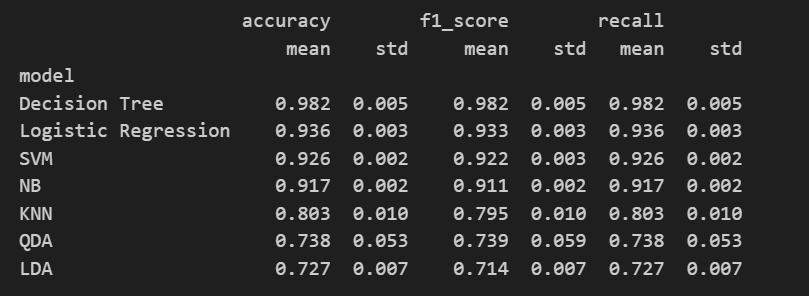

Головну метрику для оцінки я обрав f1-score, і як ми бачимо - перші 4 моделі мають доволі високе значення +0.9, що може змусити мене задуматися над тим, щоб детальніше порівняти якись з цих моделей. 

C:\Users\Admin\AppData\Local\Temp\ipykernel_15248\1870461351.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_15248\1870461351.py:2: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


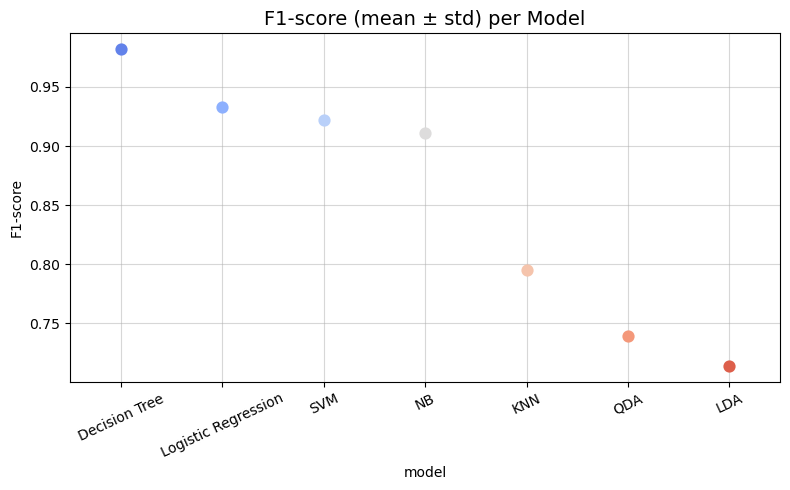

In [ ]:
plt.figure(figsize=(8,5))
sns.pointplot(
    data=summary_reset,
    x="model", y="f1_mean",
    errorbar=("sd"),
    join=False,
    palette="coolwarm",
    markers="o"
)
plt.title("F1-score (mean ± std) моделі", fontsize=14)
plt.ylabel("F1-score")
plt.xticks(rotation=25)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

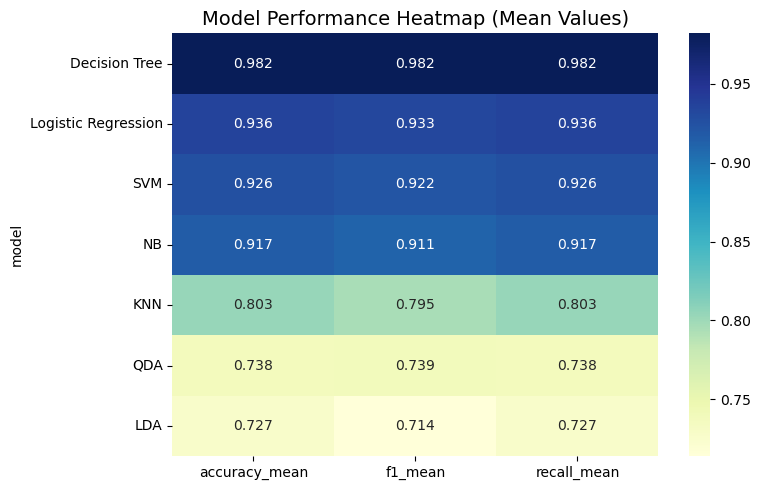

In [ ]:
heatmap_data = summary_reset.set_index("model")[["accuracy_mean", "f1_mean", "recall_mean"]]
plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Результати у вигляді Heatmap (Mean Values)", fontsize=14)
plt.tight_layout()
plt.show()

Так, як у завданні 2 я робив припущення про те, що така модель як логістична регресія може підійти для мого датасету - візьму їх для порівняння

In [139]:
best_models = {
  "Logistic Regression": LogisticRegression(max_iter=1000),
  "Decision Tree": DecisionTreeClassifier(random_state=42),
}

models_metrics = []

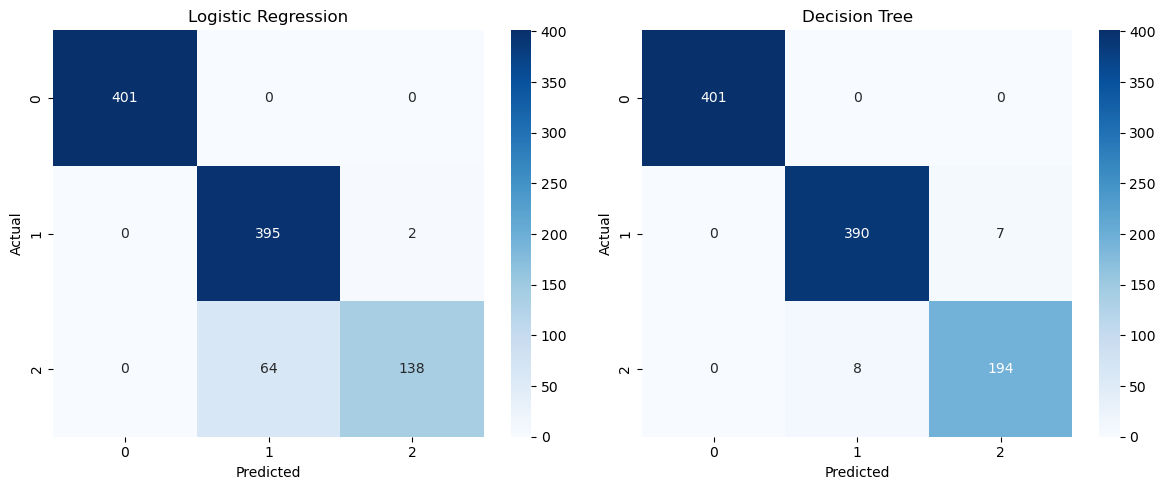

In [140]:
plt.figure(figsize=(12,5))

before_optimization = []

for i, (name, model) in enumerate(best_models.items()):
    y_pred = cross_val_predict(model, X, y, cv=5)
    cm = confusion_matrix(y, y_pred)
    
    before_optimization.append({
        "name": name,
        "f1": f1_score(y, y_pred, average="weighted"),
        "recall": recall_score(y, y_pred, average="weighted"),
        "accuracy":accuracy_score(y, y_pred)
    })
    
    plt.subplot(1, 2, i+1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

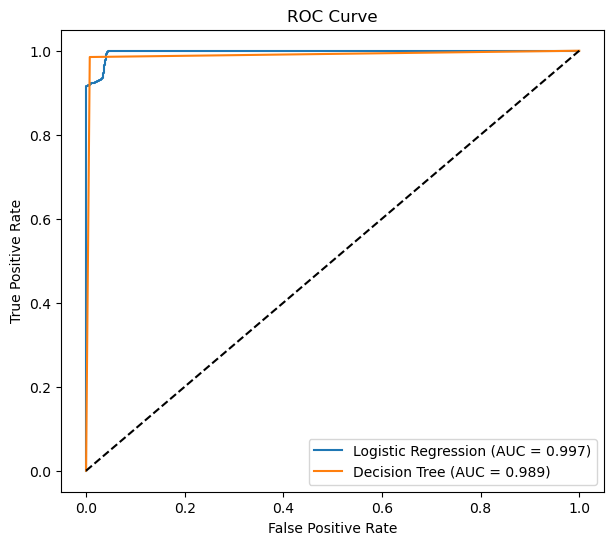

In [141]:
y_bin = label_binarize(y, classes=np.unique(y))
plt.figure(figsize=(7,6))

for name, model in best_models.items():
    y_score = cross_val_predict(model, X, y, cv=5, method='predict_proba')
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    idx = next(i for i, m in enumerate(before_optimization) if name in m["name"])
    before_optimization[idx]["roc_auc"] = roc_auc
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Тут реалізована ще одна метрика для порівняння - ROC/AUC

Ми бачимо, що дві моделі мають надзвичайно хороші значення, що означає що вони добре класифікують true positive та мінімально неправильно класифікують їх - false positive.

Але, тут видно що логічтисна регресія має кращий резльутат

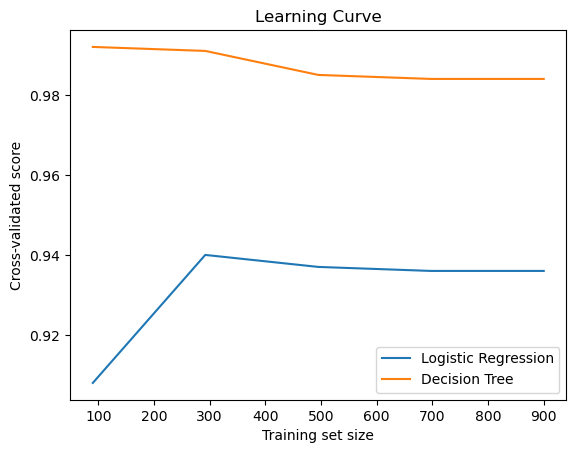

In [142]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer

f1_scorer = make_scorer(f1_score, average="weighted")

for name, model in best_models.items():
    train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=10)
    plt.plot(train_sizes, val_scores.mean(axis=1), label=name)

plt.xlabel("Training set size")
plt.ylabel("Cross-validated score")
plt.title("Learning Curve")
plt.legend()
plt.show()

На цьому зображені видно як моделі навчаються при якісь заданій кількості тренувального сету, та оцінку f1-score на тестовому сеті. Можна побачити, що дерево рішень тут має кращі результати, але при збільшенні датасету - спадає, тоді як логістична регресія має більш менш стабільний f1-score

In [126]:
class ModelMetrics(Base):
    __tablename__ = "model_metrics"

    id = Column(Integer, primary_key=True, autoincrement=True)
    model_name = Column(String, nullable=False)
    f1 = Column(Float)
    recall = Column(Float)
    accuracy = Column(Float)
    roc_auc = Column(Float) 
    hyperparams=Column(String, nullable=True)
    created_at = Column(DateTime, default=datetime.utcnow)

In [143]:
Base.metadata.create_all(engine)

for res in before_optimization:
    metric = ModelMetrics(
        model_name=res["name"],
        f1=res["f1"],
        recall=res["recall"],
        accuracy=res["accuracy"],
        roc_auc=res["roc_auc"],
    )
    session.add(metric)

session.commit()
print("Метрики успішно збережені")

Метрики успішно збережені


In [5]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
%pip install skopt
from skopt import BayesSearchCV

d:\Desktop\MECFS vs Depression Classification\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'skopt'

In [145]:
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],  
    "solver": ["liblinear"],
    "class_weight": ["balanced", None]  
}

dt_params = {
    "max_depth": [None, 5, 10, 20, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": ["balanced", None]  
}

hyperparameters = [
    logreg_params,
    dt_params
]

scoring = "f1_weighted"

Для логістичної регресії було обрано такі гіперпараметри для налаштування:

* **`C`** — коефіцієнт регуляризації, що контролює складність моделі. Менше значення означає сильнішу регуляризацію (модель простіша, менше ризику перенавчення), а більше — слабшу.
$$C = \frac{1}{λ}$$
* **`penalty`** — тип регуляризації:

  * `"l1"` — застосовується Lasso-регуляризація 
  * `"l2"` — Ridge-регуляризація 
* **`solver`** — алгоритм оптимізації. Обрано `"liblinear"`, оскільки він підтримує як `l1`, так і `l2` регуляризацію та добре підходить для невеликих і середніх за розміром датасетів.

Таким чином, налаштування `C`, `penalty` та `solver` дозволяє знайти баланс між узагальненням і точністю моделі.


Для дерева рішень підібрано такі гіперпараметри:

* **`max_depth`** — максимальна глибина дерева. Обмежує, наскільки глибоко дерево може рости, що допомагає уникнути перенавчення (чим менше значення, тим простіше дерево).
* **`min_samples_split`** — мінімальна кількість зразків, необхідна для поділу вузла. Збільшення цього параметра робить модель більш узагальнюючою.
* **`min_samples_leaf`** — мінімальна кількість зразків у листку дерева. Дозволяє уникнути створення занадто дрібних листків, що можуть відображати шум.
* **`max_features`** — кількість ознак, що враховуються при поділі.

  * `None` — використовуються всі ознаки,
  * `"sqrt"` — квадратний корінь із кількості ознак (часто використовується у випадку класифікації),
  * `"log2"` — логарифм за основою 2 від кількості ознак.

Таке налаштування дозволяє знайти компроміс між глибиною, узагальненням і стабільністю дерева.

Також, кожна модель в гіперпараметрах містить `class_weight` для того, щоб балансувати класи(додаючи їм вагу) якшо класи незбалансовані, або нічого з тим не робити

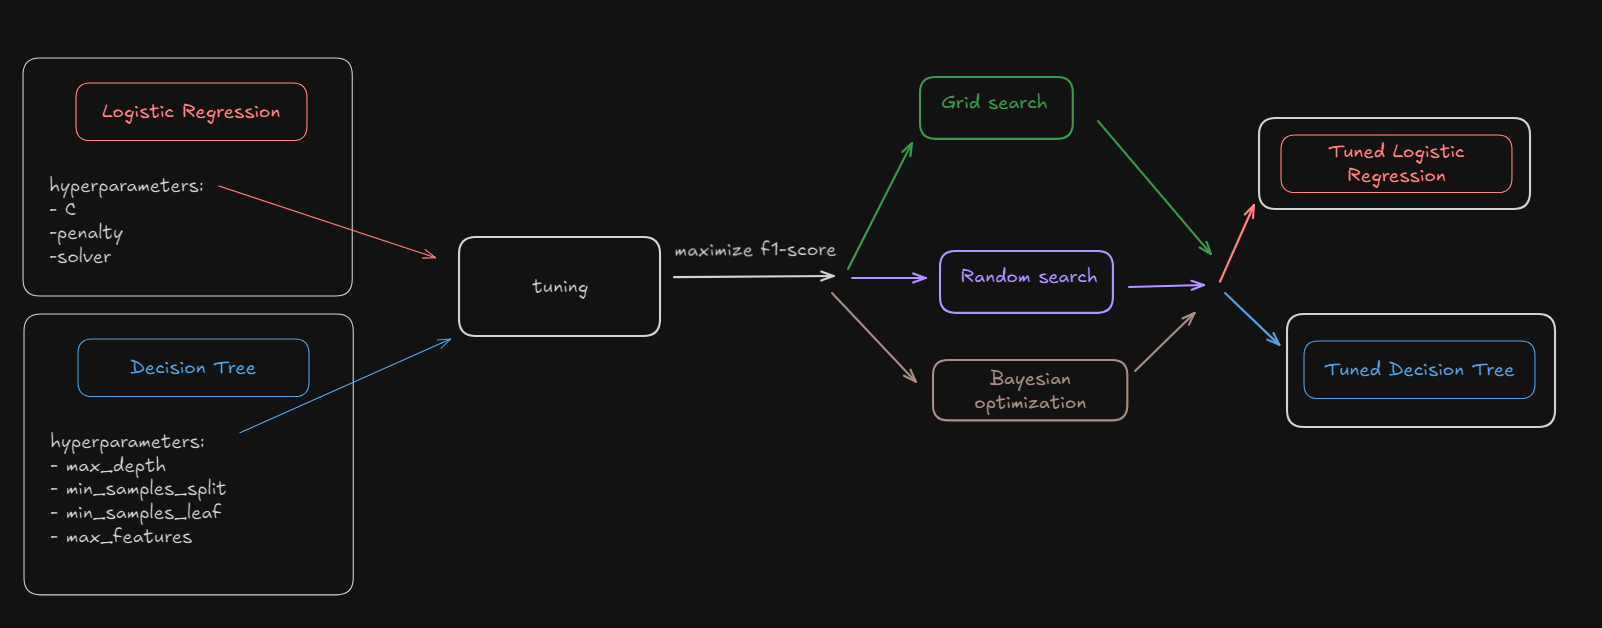

In [146]:
search_results = []
K = 5

for (name, model), param_grid in zip(best_models.items(), hyperparameters):
    print(f"\nModel: {name}")
    
    grid = GridSearchCV(model, param_grid, cv=K, scoring=scoring)
    grid.fit(X, y)
    print("GridSearchCV best score:", grid.best_score_)
    print("Best params:", grid.best_params_)
    
    randomized_results = {}
    for n_iter in [20, 30, 40]:
        randomized = RandomizedSearchCV(
            model,
            param_distributions=param_grid,
            n_iter=n_iter,
            cv=K,
            scoring=scoring,
            random_state=42
        )
        randomized.fit(X, y)
        print(f"RandomizedSearchCV n_iter={n_iter} best score:", randomized.best_score_)
        print("Best params:", randomized.best_params_)
        
        randomized_results[f"RANDOM_n_iter={n_iter}_best_score"] = randomized.best_score_
        randomized_results[f"RANDOM_n_iter={n_iter}_best_params"] = randomized.best_params_
    
    bayes = BayesSearchCV(model, param_grid, n_iter=20, cv=K, scoring=scoring, random_state=42)
    bayes.fit(X, y)
    print("BayesSearchCV best score:", bayes.best_score_)
    print("Best params:", bayes.best_params_)
    
    result_dict = {
        "Model": name,
        "GRID_best_score": grid.best_score_,
        "GRID_best_params": grid.best_params_,
        "BAYES_best_score": bayes.best_score_,
        "BAYES_best_params": bayes.best_params_
    }
    
    result_dict.update(randomized_results)
    
    search_results.append(result_dict)



Model: Logistic Regression
GridSearchCV best score: 0.9920708530884925
Best params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
RandomizedSearchCV n_iter=20 best score: 0.9920708530884925
Best params: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 20 is smaller than n_iter=30. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV n_iter=30 best score: 0.9920708530884925
Best params: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 20 is smaller than n_iter=40. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV n_iter=40 best score: 0.9920708530884925
Best params: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}


c:\Users\Admin\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1, 'balanced', 'l1', 'liblinear'] before, using random point [0.1, 'balanced', 'l1', 'liblinear']
  warnings.warn(


BayesSearchCV best score: 0.9920708530884925
Best params: OrderedDict({'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'})

Model: Decision Tree
GridSearchCV best score: 0.9890569462840443
Best params: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
RandomizedSearchCV n_iter=20 best score: 0.9890418413737351
Best params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 50, 'class_weight': 'balanced'}
RandomizedSearchCV n_iter=30 best score: 0.9890418413737351
Best params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 50, 'class_weight': 'balanced'}
RandomizedSearchCV n_iter=40 best score: 0.9890418413737351
Best params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 50, 'class_weight': 'balanced'}
BayesSearchCV best score: 0.9890418413737351
Best params: OrderedDict({'class_weight': 'ba

In [147]:
search_df = pd.DataFrame(search_results)
search_df

,Model,GRID_best_score,GRID_best_params,BAYES_best_score,BAYES_best_params,RANDOM_n_iter=20_best_score,RANDOM_n_iter=20_best_params,RANDOM_n_iter=30_best_score,RANDOM_n_iter=30_best_params,RANDOM_n_iter=40_best_score,RANDOM_n_iter=40_best_params
0,Logistic Regression,0.992071,"{'C': 1, 'class_weight': 'balanced', 'penalty'...",0.992071,"{'C': 100, 'class_weight': 'balanced', 'penalt...",0.992071,"{'solver': 'liblinear', 'penalty': 'l1', 'clas...",0.992071,"{'solver': 'liblinear', 'penalty': 'l1', 'clas...",0.992071,"{'solver': 'liblinear', 'penalty': 'l1', 'clas..."
1,Decision Tree,0.989057,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.989042,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.989042,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.989042,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.989042,"{'min_samples_split': 10, 'min_samples_leaf': ..."


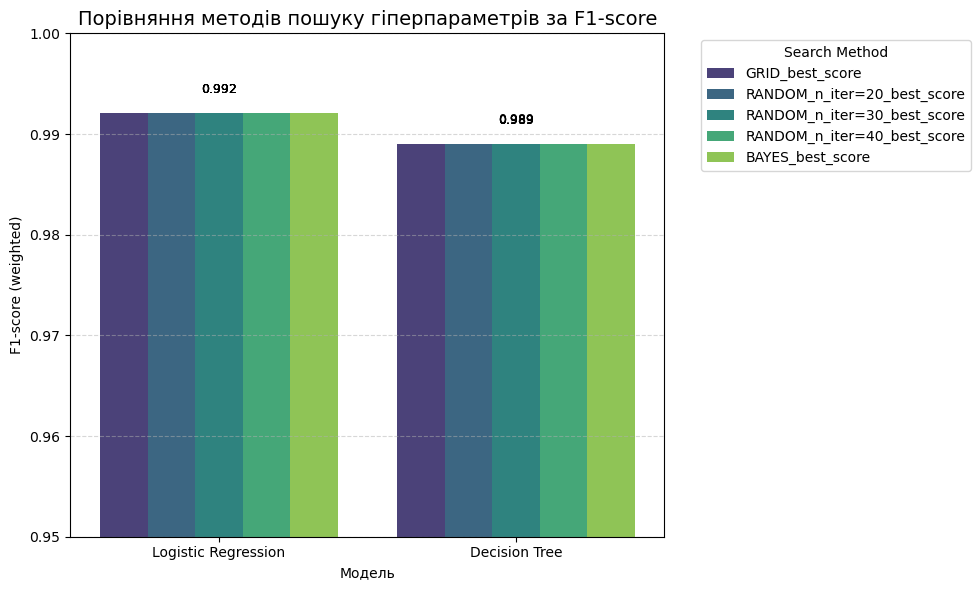

In [132]:
plot_df = search_df.melt(
    id_vars="Model",
    value_vars=[
        "GRID_best_score",
        "RANDOM_n_iter=20_best_score",
        "RANDOM_n_iter=30_best_score",
        "RANDOM_n_iter=40_best_score",
        "BAYES_best_score"
    ],
    var_name="Search_Method",
    value_name="F1_score"
)

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x="Model", y="F1_score", hue="Search_Method", palette="viridis")

for i, row in plot_df.iterrows():
    plt.text(
        x=plot_df.index[i] % len(search_df), 
        y=row.F1_score + 0.002,
        s=f"{row.F1_score:.3f}",
        ha="center", fontsize=9
    )

plt.ylim(0.95, 1)
plt.title("Порівняння методів пошуку гіперпараметрів за F1-score", fontsize=14)
plt.ylabel("F1-score (weighted)")
plt.xlabel("Модель")
plt.legend(title="Search Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [148]:
import json

after_optimization = []

best_models = [
    {"Logistic Regression": LogisticRegression},
    {"Decision Tree": DecisionTreeClassifier}
]

for i, model_dict in enumerate(best_models):
    name = list(model_dict.keys())[0]
    model_class = model_dict[name]
    
    hyperparams = search_df.loc[i, "GRID_best_params"]
    
    model_obj = model_class(**hyperparams)
    
    y_pred = cross_val_predict(model_obj, X, y, cv=5)
    
    y_score = cross_val_predict(model, X, y, cv=5, method='predict_proba')
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    after_optimization.append({
        "name": name,
        "f1": f1_score(y, y_pred, average="weighted"),
        "recall": recall_score(y, y_pred, average="weighted"),
        "accuracy":accuracy_score(y, y_pred),
        "roc_auc": roc_auc,
        "hyperparameters": json.dumps(hyperparams)
    })   
    

Після оптимізації, логістична регресія показує кращі результати, а на то є свої прични, які описані у Завданні 2 - тобто дійсно існує деякі лінійність, кореляція між деякими фічами та респонсом, і воно зіграло ключову роль, а саме тюнінг показав найкращу версію логістиної регрсесії, тоді як дерево рішено не показало якогось значного покращення

Тому, як найкращу модель я обираю логістичну регресію

In [150]:
hyperparameters = search_df.loc[0, "GRID_best_params"]

best_model = LogisticRegression(
  max_iter=1000,
  **hyperparameters
)
best_model.fit(X, y)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   solver='liblinear')

In [155]:
coefs = pd.DataFrame(best_model.coef_.T, 
                     index=X.columns, 
                     columns=["Depression", "ME/CF", "Both"])
coefs.sort_values(by="Depression", ascending=False)

,Depression,ME/CF,Both
depression_phq9_score,0.207093,-32.035966,13.340611
exercise_frequency,0.139375,-0.092638,0.046687
social_activity_level,0.116579,-0.134663,0.004910
age,0.000000,-0.113054,0.154481
pem_duration_hours,0.000000,0.000551,0.000749
brain_fog_level,0.000000,0.021211,-0.170603
physical_pain_score,0.000000,0.000000,0.000000
stress_level,0.000000,0.000000,-0.032645
hours_of_sleep_per_night,0.000000,-0.207269,0.091699
work_status_Partially_working,0.000000,0.000000,0.000000


Наша побудована логістична регрсія з 3 класами описана такою формулою:

$$P(y=k|X)=\frac{\exp(z_k)}{\sum_{j=1}^{K}\exp(z_j)}, \quad z_k=\beta_0^{(k)}+\sum_{i}\beta_i^{(k)}X_i$$

Коефіцієнти $\beta_i^{(k)}$ показують, на скільки log-odds класу k збільшуються при одиничному збільшенні ознаки $X_i$, порівняно з базовим класом.
Тепер, якщо хочемо подивитися на log-odds класу k відносно класу l:
$$
\log\text{odds}_{k/l}=\log\frac{P(y=k|X)}{P(y=l|X)}=z_k-z_l$$
Коефіцієнти $\beta_i^{(k)}$ показують, на скільки log-odds класу k збільшуються при одиничному збільшенні ознаки $X_i$, порівняно з базовим класом.

- Якщо $\beta_i^{(k)}>0$ → збільшення $X_i$ підвищує шанси класу k відносно інших.
- Якщо $\beta_i^{(k)}<0$ → збільшення $X_i$ зменшує шанси класу k.
- Якщо $\beta_i^{(k)}=0$ → ознака $X_i$ не впливає на log-odds класу k.

---

Для класу **Depression** найбільший вплив мають `pem_present` та `fatigue_severity_scale_score`, причому навяність PEM та висока втома зменшують ймовірність цього класу. Також помітно невелике позитивне підвищення ймовірності при збільшенні `depression_phq9_score`. Інші ознаки практично не впливають на передбачення цього класу.

У класі **ME/CF** ключовим фактором є `pem_present`, яка значно підвищує ймовірність, тоді як високий `depression_phq9_score` має сильний негативний ефект. Також деякий вплив на ймовірність цього класу має `hours_of_sleep_per_night`, але він менш значущий порівняно з PEM і PHQ-9.

Для класу **Both (Depression + ME/CF)** — `pem_present` та високий `depression_phq9_score`, які майже визначають ймовірність цього класу. 

Також можна побачити, що деякі фічі та коефіцієнти рівні нулю, черещ те шо під час оптимізації було вибрано штраф з Лассо - l1 penalty

---
---

12. Збережіть модель із найкращими параметрами. Серілізуйте модель у 
файл у папку models/. Зробіть це автоматично після оптимізації.

---
---

In [ ]:
import joblib

joblib.dump(best_model, "best_logistic_model.pkl")

In [8]:
loaded_model = joblib.load("../models/best_logistic_model.pkl")


d:\Desktop\MECFS vs Depression Classification\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
y_pred = loaded_model.predict(X)

f1_score(y, y_pred, average="weighted")

---
---

**13. Поясніть результати оптимізації. У звіті наведіть коротке порівняння: 
як змінились метрики після підбору параметрів, які гіперпараметри мали 
найбільший вплив.**

---
---

**До оптимізації гіперпараметрів**:
   * F1-score = 0.930
   * Recall = 0.934
   * Accuracy = 0.934
   * ROC-AUC = 0.997

**Після оптимізації гіперпараметрів**:
   * F1-score = 0.992
   * Recall = 0.992
   * Accuracy = 0.992
   * ROC-AUC = 0.989

**Висновок**:
   * Підбір гіперпараметрів значно покращив F1-score, Recall та Accuracy, що свідчить про кращу узгодженість моделі із класами даних.
   * Найбільший вплив на результат мали параметри `C=1`, `penalty='l1'` та `class_weight='balanced'`. Зокрема, **class_weight='balanced'** допоміг врахувати дисбаланс класів, а **L1-пеналізація** (`penalty='l1'`) забезпечила відбір релевантних ознак.

Оптимізація дала помітне покращення якості передбачень і підкреслила важливість правильного налаштування регуляризації та балансування класів.


----
---

**14. За необхідності — реалізуйте обробку несбалансованих класів. Якщо 
ваші дані містять дисбаланс (наприклад, 90/10), використайте техніки на 
кшталт SMOTE, class_weight, undersampling або oversampling. Поясніть свій 
вибір.**

---
---

Для моєї задачі обробка незбалансованих класів була реалізована під час оптимізації гіперпараметрів через встановлення параметра `class_weight='balanced'`





---
----

**Висновок**

---
---

В результаті моделювання та оптимізації, як модель для прогнозування діагнозу я обрав - логістичну регресію. Так, під час тренування та тестування простих дефолтних моделей, найкраще себе показало дерево рішень, але після проведення оптимізації, а саме тюнінгу за допомогою різних методів - саме логічтина регресія показала найкращий результат.

Також, варто підмітити, що припущення про дані та про модель, які були написані у 2 завданні - дійсно справдилися. Під час проведення аналізу коефіцієнтів, для кожного класу через коефіцієнти можна було побачити, які саме фічі мають найбільший вплив на діагноз, тобто можна зробити висновок, що логістична регрсія була добре навчена, зловила ті патерни в даних, та може доволі точно класифікувати ту чи іншу хворобу, з максимізованим f1_score = 0.992, при чому на тестових сетах під час крос-валідації.

Також, навчену модель, яка була перервірена на кількох тестових сетах, та порівняна з іншими моделями, я серілізував та вона повністю готова для впровадження у виробництво.

Мені дуже сподобалася ця лабораторна робота, було цікаво заглиблюватися в дані, шукати патерни, проводити порівння моделей та їхню оптимізацію. 

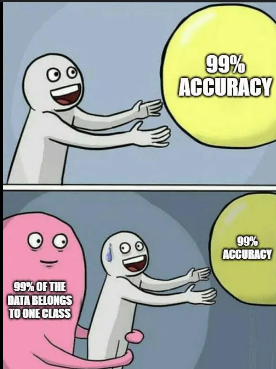